## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from rdkit_and_test_functions import smiles_to_3d,extract_3d_features,prepare_test_data

In [5]:
X_train = joblib.load("X_train.pkl")
y_train = joblib.load("y_train.pkl")

## Linear Regression

In [6]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [7]:
X_test, y_test, test_smiles = prepare_test_data(
    X_train.columns
)

X column names:
smiles

y column name:
electrochemical_gap
X_test shape: (212, 11)
y_test shape: (212,)


In [8]:
y_pred = ridge_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("HOPV15 Results")
print("----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

HOPV15 Results
----------------
MAE : 0.9205313977243438
RMSE: 1.2099188240512886
R²  : -11.609625981956002


In [9]:
results = pd.DataFrame({
    "SMILES": test_smiles,
    "Experimental_Gap": y_test,
    "Predicted_Gap": y_pred,
    "Absolute_Error": np.abs(y_test - y_pred)
})

results.to_csv("HOPV15_predictions.csv", index=False)

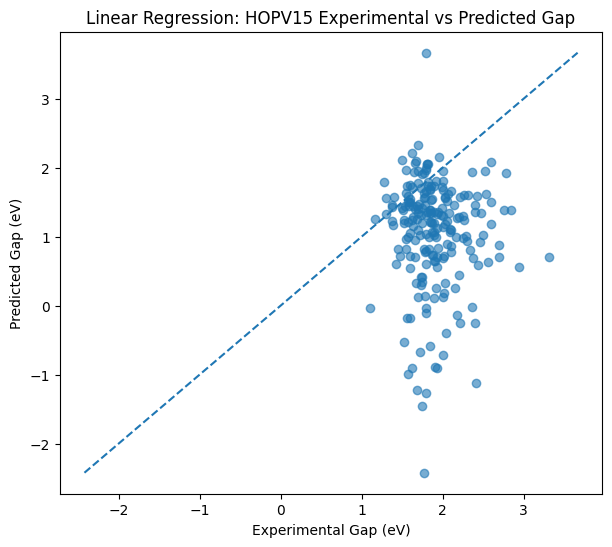

In [10]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Experimental Gap (eV)")
plt.ylabel("Predicted Gap (eV)")
plt.title("Linear Regression: HOPV15 Experimental vs Predicted Gap")

plt.show()

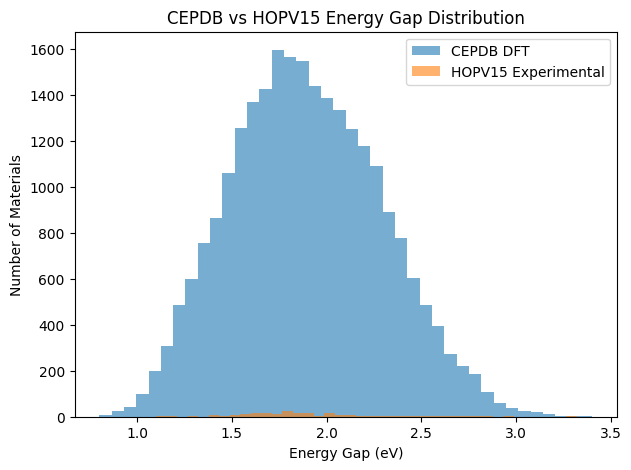

In [11]:
plt.figure(figsize=(7,5))

plt.hist(y_train, bins=40, alpha=0.6, label="CEPDB DFT")
plt.hist(y_test, bins=40, alpha=0.6, label="HOPV15 Experimental")

plt.xlabel("Energy Gap (eV)")
plt.ylabel("Number of Materials")
plt.title("CEPDB vs HOPV15 Energy Gap Distribution")
plt.legend()
plt.show()